## 1. Imports


In [ ]:
import os
import random
import pickle
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import Audio, display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import shuffle
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (BatchNormalization, Concatenate, Conv1D, Dense,
                                     Dropout, GlobalAveragePooling1D, Input,
                                     MaxPooling1D, ReLU)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TARGET_SR = 22_050
DURATION = 4.0
TARGET_SAMPLES = int(TARGET_SR * DURATION)
MAX_LEN = 300
BATCH_SIZE = 64
EPOCHS = 120

# print("TensorFlow:", tf.__version__)
# print("Librosa:", librosa.__version__)


2026-05-11 19:49:50.869327: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778528991.079721      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778528991.139316      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778528991.616585      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778528991.616623      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778528991.616626      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Librosa: 0.11.0


## 2. Load Dataset


In [2]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip -d /kaggle/working/ravdess_audio_data/


Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100%|█████████████████████████████████████████| 429M/429M [00:02<00:00, 197MB/s]



In [ ]:
DATASET_PATH = Path("/kaggle/working/ravdess_audio_data")
# if not DATASET_PATH.exists():
#     DATASET_PATH = Path("ravdess_audio_data")

EMOTION_MAP = {
    "01": "neutral",
    #"02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

records = []
for audio_path in DATASET_PATH.rglob("*.wav"):
    parts = audio_path.stem.split("-")   #03-01-03-01-01-01-01.wav
    if len(parts) >= 7 and parts[2] in EMOTION_MAP:
        records.append({
            "path": str(audio_path),
            "filename": audio_path.name,
            "emotion": EMOTION_MAP[parts[2]],
            "emotion_id": parts[2],
            "actor": parts[-1],
            "intensity": parts[3],
            "statement": parts[4],
            "repetition": parts[5],
        })

df = pd.DataFrame(records).sort_values("path").reset_index(drop=True)

if df.empty:
    raise FileNotFoundError(
        f"No RAVDESS .wav files found under {DATASET_PATH}. Run the download/unzip cell first."
    )

display(df.head())
print("Dataset path:", DATASET_PATH)
print("Total samples:", len(df))
print("Emotions:", sorted(df["emotion"].unique()))


,path,filename,emotion,emotion_id,actor,intensity,statement,repetition
0,/kaggle/working/ravdess_audio_data/Actor_01/03...,03-01-01-01-01-01-01.wav,neutral,01,01,01,01,01
1,/kaggle/working/ravdess_audio_data/Actor_01/03...,03-01-01-01-01-02-01.wav,neutral,01,01,01,01,02
2,/kaggle/working/ravdess_audio_data/Actor_01/03...,03-01-01-01-02-01-01.wav,neutral,01,01,01,02,01
3,/kaggle/working/ravdess_audio_data/Actor_01/03...,03-01-01-01-02-02-01.wav,neutral,01,01,01,02,02
4,/kaggle/working/ravdess_audio_data/Actor_01/03...,03-01-03-01-01-01-01.wav,happy,03,01,01,01,01


Dataset path: /kaggle/working/ravdess_audio_data
Total samples: 2496
Emotions: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


## 3. EDA


,path,filename,emotion,emotion_id,actor,intensity,statement,repetition
count,2496,2496,2496,2496,2496,2496,2496,2496
unique,2496,1248,7,7,24,2,2,2
top,/kaggle/working/ravdess_audio_data/audio_speec...,03-01-04-01-01-01-24.wav,happy,03,01,01,01,01
freq,1,2,384,384,104,1344,1248,1248


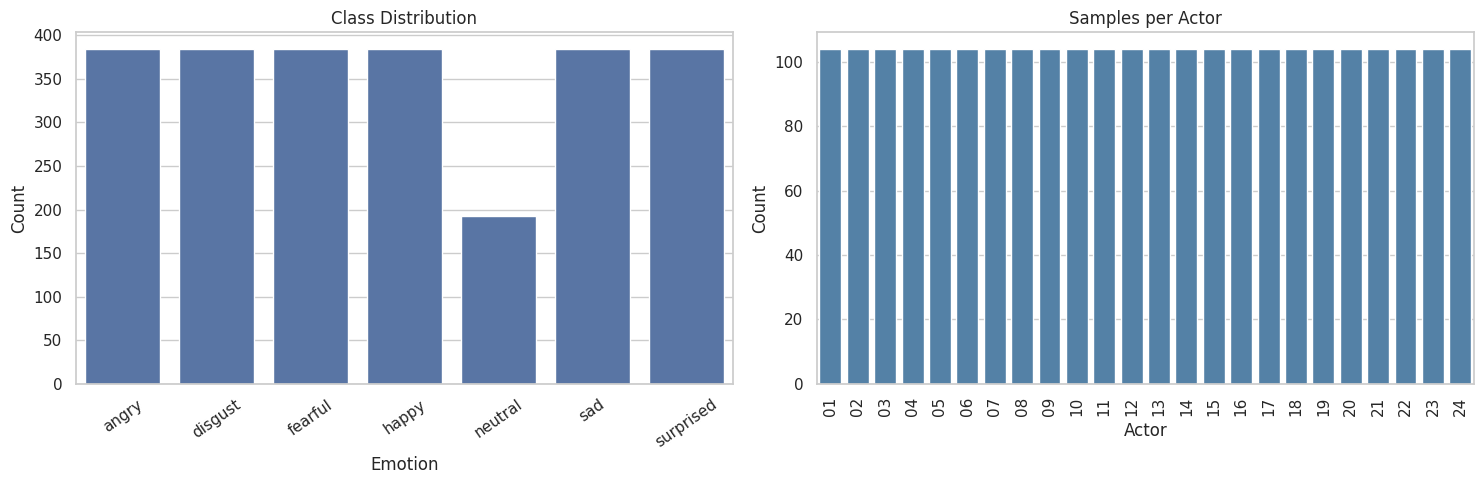

Sample: 03-01-01-01-02-02-21.wav | Emotion: neutral


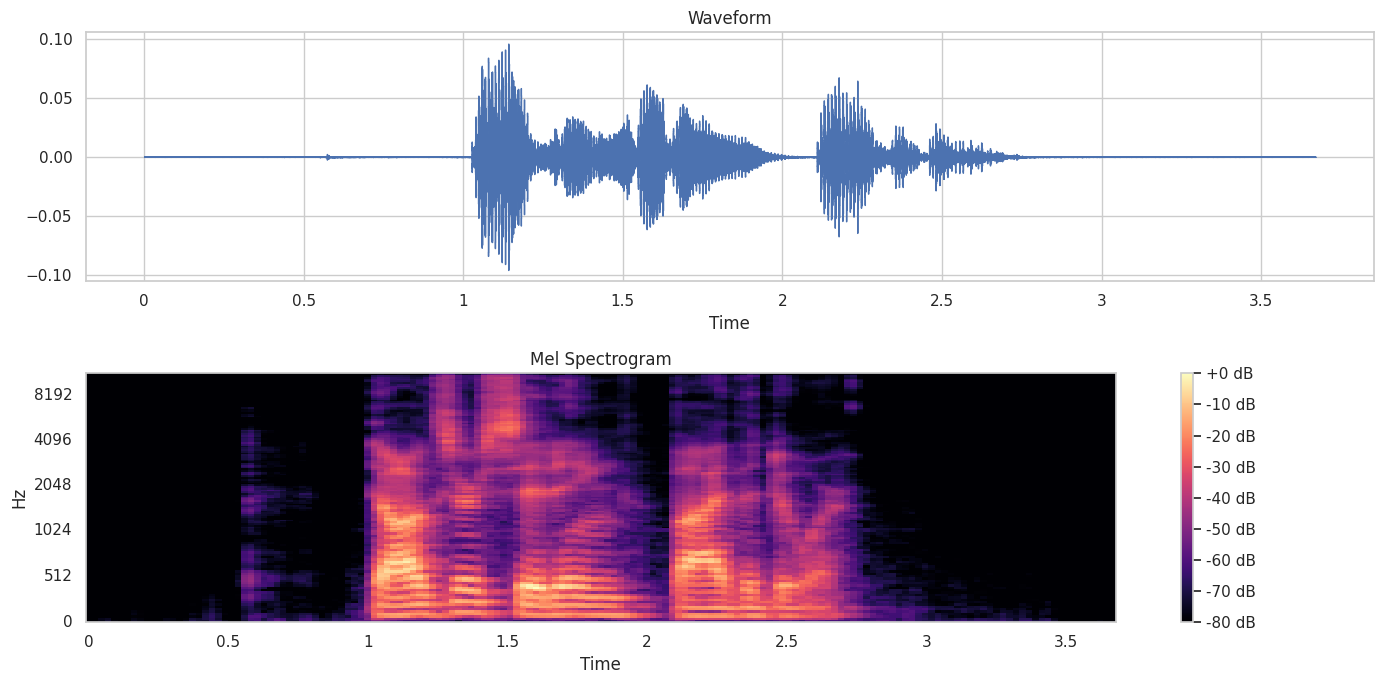

In [ ]:
display(df.describe(include="all"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x="emotion", order=sorted(df["emotion"].unique()), ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=35)

actor_counts = df.groupby("actor").size().sort_index()
sns.barplot(x=actor_counts.index, y=actor_counts.values, ax=axes[1], color="steelblue")
axes[1].set_title("Samples per Actor")
axes[1].set_xlabel("Actor")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

sample_row = df.sample(1, random_state=SEED).iloc[0]
sample_audio, sample_sr = librosa.load(sample_row["path"], sr=TARGET_SR, duration=DURATION)

print(f"Sample: {sample_row['filename']} | Emotion: {sample_row['emotion']}")
display(Audio(sample_audio, rate=sample_sr))

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
librosa.display.waveshow(sample_audio, sr=sample_sr, ax=axes[0])
axes[0].set_title("Waveform")

mel = librosa.feature.melspectrogram(y=sample_audio, sr=sample_sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sample_sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Mel Spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()


## 4. Preprocessing Functions


In [ ]:
def load_audio(path, sr=TARGET_SR, duration=DURATION):
    y, sr = librosa.load(path, sr=sr, duration=duration)
    return y.astype(np.float32), sr

def fix_audio_length(y, target_samples=TARGET_SAMPLES):
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)), mode="constant")
    else:
        y = y[:target_samples]
    return y.astype(np.float32)


def preprocess_audio(path, sr=TARGET_SR, duration=DURATION, trim=True):
    y, sr = load_audio(path, sr=sr, duration=duration)
    y = fix_audio_length(y, int(sr * duration))
    return y, sr


## 5. Augmentation Functions


In [ ]:
def add_noise(y, noise_factor=0.005):
    noise = np.random.normal(0, 1, len(y)).astype(np.float32)
    return (y + noise_factor * noise).astype(np.float32)


def time_shift(y, sr=TARGET_SR, shift_max_seconds=0.25):
    max_shift = int(sr * shift_max_seconds)
    shift_amount = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(y, shift_amount).astype(np.float32)

def augment_audio(y, sr, methods=("noise", "shift")):
    augmented = []
    for method in methods:
        if method == "noise":
            y_aug = add_noise(y)
        elif method == "shift":
            y_aug = time_shift(y, sr=sr)
        else:
            raise ValueError(f"Unknown augmentation method: {method}")
        augmented.append(fix_audio_length(y_aug, int(sr * DURATION)))
    return augmented


AUGMENTATION_METHODS = ("noise", "shift")


## 6. Feature Extraction Functions


In [ ]:
def compute_features(y, sr=TARGET_SR):
    hop_length = int(0.010 * sr)
    n_fft = int(0.025 * sr)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=40,
        hop_length=hop_length,
        n_fft=n_fft,
    ).T

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        hop_length=hop_length,
        n_fft=n_fft,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max).T

    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr,
        n_chroma=12,
        hop_length=hop_length,
        n_fft=n_fft,
    ).T

    return mfcc.astype(np.float32), mel_db.astype(np.float32), chroma.astype(np.float32)


def pad_feature_list(feature_list, max_len=MAX_LEN):
    return pad_sequences(
        feature_list,
        maxlen=max_len,
        dtype="float32",
        padding="post",
        truncating="post",
        value=0.0,
    )


def extract_feature_set(paths, labels):
    X_mfcc, X_mel, X_chroma, y_labels, valid_paths, errors = [], [], [], [], [], []

    for path, label in zip(paths, labels):
        try:
            y, sr = preprocess_audio(path)
            mfcc, mel, chroma = compute_features(y, sr)
            X_mfcc.append(mfcc)
            X_mel.append(mel)
            X_chroma.append(chroma)
            y_labels.append(label)
            valid_paths.append(path)
        except Exception as exc:
            errors.append((path, str(exc)))

    return X_mfcc, X_mel, X_chroma, y_labels, valid_paths, errors


## 7. Extract Original Features


In [ ]:
X_mfcc_raw, X_mel_raw, X_chroma_raw, y_labels, valid_paths, extraction_errors = extract_feature_set(
    df["path"].tolist(),
    df["emotion"].tolist(),
)

if extraction_errors:
    print(f"Skipped {len(extraction_errors)} files because of extraction errors.")
    display(pd.DataFrame(extraction_errors, columns=["path", "error"]).head())

X_mfcc = pad_feature_list(X_mfcc_raw)
X_mel = pad_feature_list(X_mel_raw)
X_chroma = pad_feature_list(X_chroma_raw)
y_labels = np.array(y_labels)
valid_paths = np.array(valid_paths)

print("MFCC shape:", X_mfcc.shape)
print("Mel shape:", X_mel.shape)
print("Chroma shape:", X_chroma.shape)
print("Labels shape:", y_labels.shape)


MFCC shape: (2496, 300, 40)
Mel shape: (2496, 300, 128)
Chroma shape: (2496, 300, 12)
Labels shape: (2496,)


## 8. Label Encoding


In [9]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded, num_classes=len(label_encoder.classes_))

print("Classes:", list(label_encoder.classes_))
print("Encoded labels shape:", y_categorical.shape)


Classes: [np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Encoded labels shape: (2496, 7)


## 9. Train/Test Split


In [10]:
(
    X_train_mfcc,
    X_test_mfcc,
    X_train_mel,
    X_test_mel,
    X_train_chroma,
    X_test_chroma,
    y_train,
    y_test,
    train_paths,
    test_paths,
    train_label_names,
    test_label_names,
) = train_test_split(
    X_mfcc,
    X_mel,
    X_chroma,
    y_categorical,
    valid_paths,
    y_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=y_labels,
)

print("Train samples:", len(y_train))
print("Test samples:", len(y_test))
print("Train MFCC:", X_train_mfcc.shape)
print("Test MFCC:", X_test_mfcc.shape)


Train samples: 1996
Test samples: 500
Train MFCC: (1996, 300, 40)
Test MFCC: (500, 300, 40)


## 10. Augmentation on Train Only


In [11]:
aug_mfcc_raw, aug_mel_raw, aug_chroma_raw, aug_labels = [], [], [], []

for path, label in zip(train_paths, train_label_names):
    try:
        y, sr = preprocess_audio(path)
        for y_aug in augment_audio(y, sr, methods=AUGMENTATION_METHODS):
            mfcc, mel, chroma = compute_features(y_aug, sr)
            aug_mfcc_raw.append(mfcc)
            aug_mel_raw.append(mel)
            aug_chroma_raw.append(chroma)
            aug_labels.append(label)
    except Exception as exc:
        print(f"Augmentation skipped for {path}: {exc}")

if aug_labels:
    X_aug_mfcc = pad_feature_list(aug_mfcc_raw)
    X_aug_mel = pad_feature_list(aug_mel_raw)
    X_aug_chroma = pad_feature_list(aug_chroma_raw)
    y_aug = to_categorical(
        label_encoder.transform(aug_labels),
        num_classes=len(label_encoder.classes_),
    )

    X_train_mfcc = np.concatenate([X_train_mfcc, X_aug_mfcc], axis=0)
    X_train_mel = np.concatenate([X_train_mel, X_aug_mel], axis=0)
    X_train_chroma = np.concatenate([X_train_chroma, X_aug_chroma], axis=0)
    y_train = np.concatenate([y_train, y_aug], axis=0)

X_train_mfcc, X_train_mel, X_train_chroma, y_train = shuffle(
    X_train_mfcc,
    X_train_mel,
    X_train_chroma,
    y_train,
    random_state=SEED,
)

print("Train samples after augmentation:", len(y_train))
print("Test samples stayed unchanged:", len(y_test))


Train samples after augmentation: 5988
Test samples stayed unchanged: 500


## 11. Feature Scaling


In [ ]:
def fit_transform_3d(train_array, test_array):#Train MFCC: (1996, 300, 40)
    scaler = StandardScaler()
    n_features = train_array.shape[-1]

    train_2d = train_array.reshape(-1, n_features) #(1996*300, 40)
    test_2d = test_array.reshape(-1, n_features)

    scaler.fit(train_2d) 

    train_scaled = scaler.transform(train_2d).reshape(train_array.shape).astype(np.float32)
    test_scaled = scaler.transform(test_2d).reshape(test_array.shape).astype(np.float32)
    return train_scaled, test_scaled, scaler


X_train_mfcc, X_test_mfcc, mfcc_scaler = fit_transform_3d(X_train_mfcc, X_test_mfcc)
X_train_mel, X_test_mel, mel_scaler = fit_transform_3d(X_train_mel, X_test_mel)
X_train_chroma, X_test_chroma, chroma_scaler = fit_transform_3d(X_train_chroma, X_test_chroma)

feature_scalers = {
    "mfcc": mfcc_scaler,
    "mel": mel_scaler,
    "chroma": chroma_scaler,
}

print("Scaled MFCC mean/std:", round(float(X_train_mfcc.mean()), 4), round(float(X_train_mfcc.std()), 4))
print("Scaled Mel mean/std:", round(float(X_train_mel.mean()), 4), round(float(X_train_mel.std()), 4))
print("Scaled Chroma mean/std:", round(float(X_train_chroma.mean()), 4), round(float(X_train_chroma.std()), 4))


Scaled MFCC mean/std: 0.0 1.0
Scaled Mel mean/std: -0.0 1.0
Scaled Chroma mean/std: 0.0 1.0


## 12. Build Multi-Branch CNN


In [17]:
def cnn_branch(inputs, name_prefix):
    x = Conv1D(128, kernel_size=5, padding="same", name=f"{name_prefix}_conv1")(inputs)
    x = BatchNormalization(name=f"{name_prefix}_bn1")(x)
    x = ReLU(name=f"{name_prefix}_relu1")(x)
    x = MaxPooling1D(pool_size=2, name=f"{name_prefix}_pool1")(x)
    x = Dropout(0.40, name=f"{name_prefix}_drop1")(x)

    x = Conv1D(64, kernel_size=3, padding="same", name=f"{name_prefix}_conv2")(x)
    x = BatchNormalization(name=f"{name_prefix}_bn2")(x)
    x = ReLU(name=f"{name_prefix}_relu2")(x)
    x = MaxPooling1D(pool_size=2, name=f"{name_prefix}_pool2")(x)
    x = Dropout(0.30, name=f"{name_prefix}_drop2")(x)

    x = Conv1D(32, kernel_size=3, padding="same", name=f"{name_prefix}_conv3")(x)
    x = BatchNormalization(name=f"{name_prefix}_bn3")(x)
    x = ReLU(name=f"{name_prefix}_relu3")(x)
    x = MaxPooling1D(pool_size=2, name=f"{name_prefix}_pool3")(x)
    x = Dropout(0.20, name=f"{name_prefix}_drop3")(x)

    return GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)


def build_multi_branch_cnn(mfcc_shape, mel_shape, chroma_shape, num_classes):
    mfcc_input = Input(shape=mfcc_shape, name="mfcc_input")
    mel_input = Input(shape=mel_shape, name="mel_input")
    chroma_input = Input(shape=chroma_shape, name="chroma_input")

    mfcc_branch = cnn_branch(mfcc_input, "mfcc")
    mel_branch = cnn_branch(mel_input, "mel")
    chroma_branch = cnn_branch(chroma_input, "chroma")

    merged = Concatenate(name="feature_fusion")([mfcc_branch, mel_branch, chroma_branch])
    x = Dense(128, activation="relu", name="dense_128")(merged)
    x = Dropout(0.40, name="dense_dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="emotion_output")(x)

    return Model(inputs=[mfcc_input, mel_input, chroma_input], outputs=outputs, name="ravdess_multi_branch_cnn")


model = build_multi_branch_cnn(
    mfcc_shape=X_train_mfcc.shape[1:],
    mel_shape=X_train_mel.shape[1:],
    chroma_shape=X_train_chroma.shape[1:],
    num_classes=len(label_encoder.classes_),
)

model.summary()


Model: "ravdess_multi_branch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc_input          │ (None, 300, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_input           │ (None, 300, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_input        │ (None, 300, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_conv1 (Conv1D) │ (None, 300, 128)  │     25,728 │ mfcc_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_conv1 (Conv1D)  │ (None, 300, 128)  │     82,048 │ mel_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_conv1        │ (None, 300, 128)  │      7,808 │ chroma_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_bn1            │ (None, 300, 128)  │        512 │ mfcc_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_bn1             │ (None, 300, 128)  │        512 │ mel_conv1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_bn1          │ (None, 300, 128)  │        512 │ chroma_conv1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_relu1 (ReLU)   │ (None, 300, 128)  │          0 │ mfcc_bn1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_relu1 (ReLU)    │ (None, 300, 128)  │          0 │ mel_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_relu1 (ReLU) │ (None, 300, 128)  │          0 │ chroma_bn1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_pool1          │ (None, 150, 128)  │          0 │ mfcc_relu1[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_pool1           │ (None, 150, 128)  │          0 │ mel_relu1[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_pool1        │ (None, 150, 128)  │          0 │ chroma_relu1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_drop1          │ (None, 150, 128)  │          0 │ mfcc_pool1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mel_drop1 (Dropout) │ (None, 150, 128)  │          0 │ mel_pool1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ chroma_drop1        │ (None, 150, 128)  │          0 │ chroma_pool1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_conv2 (Conv1D) │ (None, 150, 64)   │     24,640 │ mfcc_drop1[0][0]

 Total params: 224,039 (875.15 KB)

 Trainable params: 222,695 (869.90 KB)

 Non-trainable params: 1,344 (5.25 KB)

## 13. Compile Model


In [18]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


## 14. Callbacks


In [19]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        "best_emotion_model.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]


## 15. Training


In [20]:
history = model.fit(
    [X_train_mfcc, X_train_mel, X_train_chroma],
    y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)


Epoch 1/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.1652 - loss: 2.0318
Epoch 1: val_accuracy improved from -inf to 0.23915, saving model to best_emotion_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 173ms/step - accuracy: 0.1654 - loss: 2.0312 - val_accuracy: 0.2392 - val_loss: 1.8778 - learning_rate: 1.0000e-04
Epoch 2/120
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2242 - loss: 1.8736
Epoch 2: val_accuracy improved from 0.23915 to 0.25584, saving model to best_emotion_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2248 - loss: 1.8728 - val_accuracy: 0.2558 - val_loss: 1.8268 - learning_rate: 1.0000e-04
Epoch 3/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2701 - loss: 1.7911
Epoch 3: val_accuracy improved from 0.25584 to 0.30590, saving model to best_emotion_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2703 - loss: 1.7909 - val_accuracy: 0.3059 - val_loss: 1.7827 - learning_rate: 1.0000e-04
Epoch 4/120
79/80 ━

## 16. Plot Curves


,accuracy,loss,val_accuracy,val_loss,learning_rate
115,0.893496,0.310011,0.812013,0.524462,0.000025
116,0.890155,0.321422,0.808676,0.505881,0.000025
117,0.893889,0.315214,0.810901,0.520168,0.000025
118,0.890941,0.314246,0.813126,0.525731,0.000025
119,0.894871,0.311776,0.814238,0.521102,0.000025


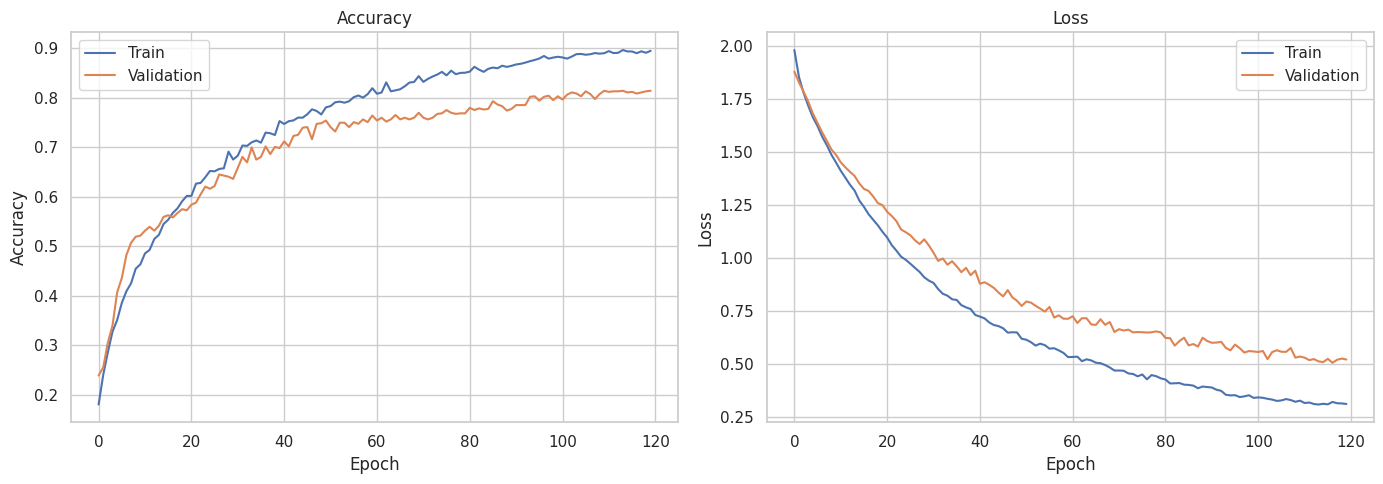

In [21]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["accuracy"], label="Train")
axes[0].plot(history_df["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_df["loss"], label="Train")
axes[1].plot(history_df["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 17. Evaluation Metrics


In [22]:
test_loss, test_accuracy = model.evaluate(
    [X_test_mfcc, X_test_mel, X_test_chroma],
    y_test,
    verbose=0,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

y_prob = model.predict([X_test_mfcc, X_test_mel, X_test_chroma], verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))


Test loss: 0.2827
Test accuracy: 0.9200
              precision    recall  f1-score   support

       angry       0.94      0.99      0.96        77
     disgust       1.00      0.86      0.92        77
     fearful       0.90      0.96      0.93        77
       happy       1.00      0.84      0.92        77
     neutral       0.68      1.00      0.81        38
         sad       1.00      0.84      0.92        77
   surprised       0.89      0.99      0.94        77

    accuracy                           0.92       500
   macro avg       0.92      0.93      0.91       500
weighted avg       0.93      0.92      0.92       500



## 18. Confusion Matrix


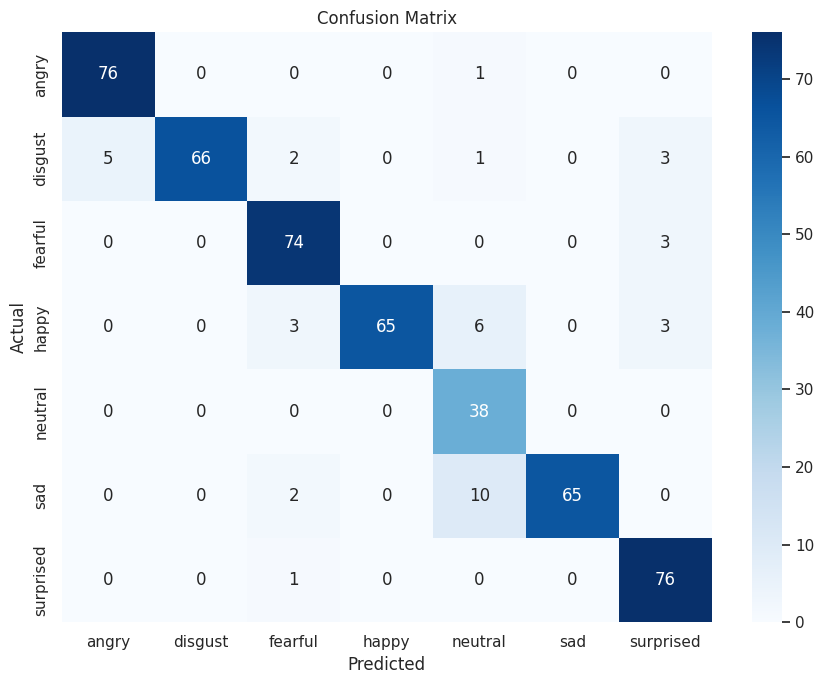

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 19. Single Audio Prediction


In [24]:
def transform_3d(array, scaler):
    n_features = array.shape[-1]
    return scaler.transform(array.reshape(-1, n_features)).reshape(array.shape).astype(np.float32)


def predict_emotion(audio_path):
    y, sr = preprocess_audio(audio_path)
    mfcc, mel, chroma = compute_features(y, sr)

    mfcc = pad_feature_list([mfcc])
    mel = pad_feature_list([mel])
    chroma = pad_feature_list([chroma])

    mfcc = transform_3d(mfcc, feature_scalers["mfcc"])
    mel = transform_3d(mel, feature_scalers["mel"])
    chroma = transform_3d(chroma, feature_scalers["chroma"])

    probabilities = model.predict([mfcc, mel, chroma], verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_emotion = label_encoder.inverse_transform([predicted_index])[0]

    return predicted_emotion, float(probabilities[predicted_index]), pd.Series(
        probabilities,
        index=label_encoder.classes_,
    ).sort_values(ascending=False)


sample_path = test_paths[0]
predicted_emotion, confidence, probabilities = predict_emotion(sample_path)

print("Audio:", sample_path)
print("True emotion:", test_label_names[0])
print(f"Predicted emotion: {predicted_emotion} ({confidence:.2%})")
display(probabilities.to_frame("probability"))
display(Audio(filename=sample_path))


Audio: /kaggle/working/ravdess_audio_data/audio_speech_actors_01-24/Actor_19/03-01-04-02-02-02-19.wav
True emotion: sad
Predicted emotion: sad (92.52%)


,probability
sad,9.252352e-01
fearful,5.672864e-02
neutral,1.058590e-02
happy,3.725404e-03
surprised,3.401506e-03
disgust,3.230788e-04
angry,2.742949e-07


## 20. Save Model


In [25]:
MODEL_PATH = "emotion_model_enhanced.h5"
LABEL_ENCODER_PATH = "label_encoder_enhanced.pkl"
SCALERS_PATH = "feature_scalers_enhanced.pkl"

model.save(MODEL_PATH)

with open(LABEL_ENCODER_PATH, "wb") as f:
    pickle.dump(label_encoder, f)

with open(SCALERS_PATH, "wb") as f:
    pickle.dump(feature_scalers, f)

print("Saved:")
print("-", MODEL_PATH)
print("-", LABEL_ENCODER_PATH)
print("-", SCALERS_PATH)


Saved:
- emotion_model_enhanced.h5
- label_encoder_enhanced.pkl
- feature_scalers_enhanced.pkl
